In [1]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, vstack, hstack, join
import fitsio

sys.path.append(os.path.expanduser('~/git/desi-lrg-selection'))
import plotting_scripts as lrg_plot
import importlib
importlib.reload(lrg_plot)

<module 'plotting_scripts' from '/global/homes/r/rongpu/git/desi-lrg-selection/plotting_scripts.py'>

In [2]:
params = {'legend.fontsize': 'x-large',
         'axes.labelsize': 'x-large',
         'axes.titlesize':'x-large',
         'xtick.labelsize':'x-large',
         'ytick.labelsize':'x-large',
         'figure.facecolor':'w'} 
plt.rcParams.update(params)

In [3]:
cat0 = Table(fitsio.read('/global/cscratch1/sd/rongpu/target/catalogs/dr9.0/0.49.0/dr9_sv1_lrg_south_0.49.0_basic.fits'))
cat = Table(fitsio.read('/global/cscratch1/sd/rongpu/target/catalogs/dr9.0/0.49.0/dr9_sv1_lrg_south_0.49.0_photom.fits'))
cat1 = Table(fitsio.read('/global/cscratch1/sd/rongpu/target/catalogs/dr9.0/0.49.0/dr9_sv1_lrg_south_0.49.0_more_1.fits'))
cat = hstack([cat0, cat, cat1], join_type='exact')
print(len(cat))

31485458


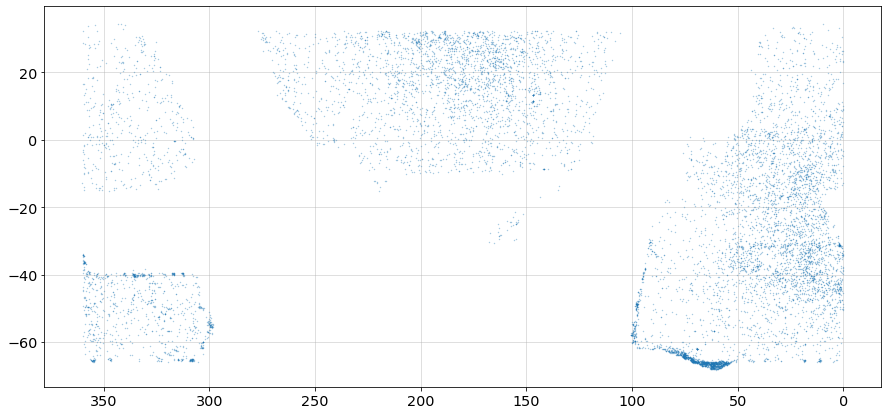

In [4]:
mask = cat['GAIA_PHOT_G_MEAN_MAG']!=0
# mask &= (cat['GAIA_ASTROMETRIC_EXCESS_NOISE']<10**0.5)
mask &= (cat['GAIA_PHOT_G_MEAN_MAG'] < 17)

plt.figure(figsize=(15, 7))
plt.plot(cat['RA'][mask], cat['DEC'][mask], '.', ms=0.7, alpha=0.5)
plt.grid(alpha=0.5)
plt.gca().invert_xaxis()
plt.show()

In [5]:
mask = cat['DEC']>-30
cat = cat[mask]
print(len(cat))

24978592


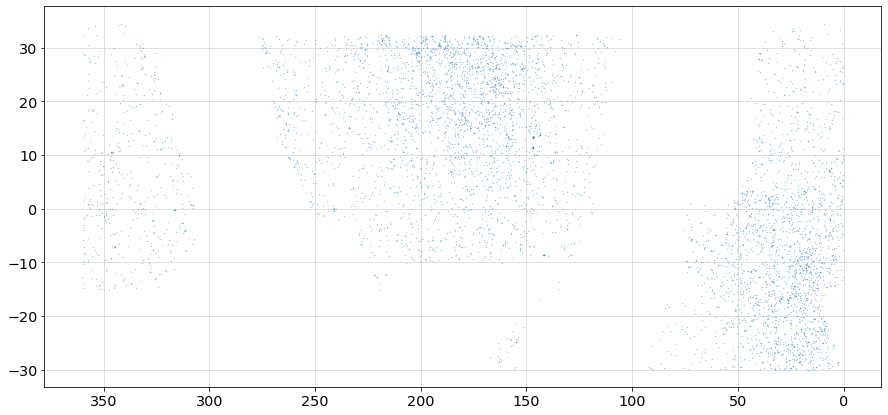

In [6]:
mask = cat['GAIA_PHOT_G_MEAN_MAG']!=0
# mask &= (cat['GAIA_ASTROMETRIC_EXCESS_NOISE']<10**0.5)
mask &= (cat['GAIA_PHOT_G_MEAN_MAG'] < 17)

plt.figure(figsize=(15, 7))
plt.plot(cat['RA'][mask], cat['DEC'][mask], '.', ms=0.7, alpha=0.5)
plt.grid(alpha=0.5)
plt.gca().invert_xaxis()
plt.show()

In [7]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    cat['gmag'] = 22.5 - 2.5*np.log10(cat['FLUX_G']/cat['MW_TRANSMISSION_G'])
    cat['rmag'] = 22.5 - 2.5*np.log10(cat['FLUX_R']/cat['MW_TRANSMISSION_R'])
    cat['zmag'] = 22.5 - 2.5*np.log10(cat['FLUX_Z']/cat['MW_TRANSMISSION_Z'])
    cat['w1mag'] = 22.5 - 2.5*np.log10(cat['FLUX_W1']/cat['MW_TRANSMISSION_W1'])
    cat['w2mag'] = 22.5 - 2.5*np.log10(cat['FLUX_W2']/cat['MW_TRANSMISSION_W2'])
    cat['rfibermag'] = 22.5 - 2.5*np.log10(cat['FIBERFLUX_R']/cat['MW_TRANSMISSION_R'])
    cat['zfibermag'] = 22.5 - 2.5*np.log10(cat['FIBERFLUX_Z']/cat['MW_TRANSMISSION_Z'])

In [8]:
lrg_opt = cat['SV1_DESI_TARGET'] & 2**3 > 0
print(np.sum(lrg_opt)/len(cat))

lrg_ir = cat['SV1_DESI_TARGET'] & 2**4 > 0
print(np.sum(lrg_ir)/len(cat))

0.2791608510199454
0.2878260311870261


In [10]:
mask_qso = cat['SV1_DESI_TARGET'] & 2**2 > 0
print(np.sum(mask_qso)/len(cat))

0.011656381592685448


In [11]:
mask = cat['MORPHTYPE']=='PSF'
print(np.sum(mask)/len(cat))

0.06464211433534764


In [12]:
mask = cat['GAIA_PHOT_G_MEAN_MAG']!=0
print(np.sum(mask)/len(cat))

0.01354728080750108


In [13]:
mask = cat['GAIA_PHOT_G_MEAN_MAG']!=0
mask &= cat['GAIA_PHOT_G_MEAN_MAG']<18
print(np.sum(mask)/len(cat))

0.00043985665805342433


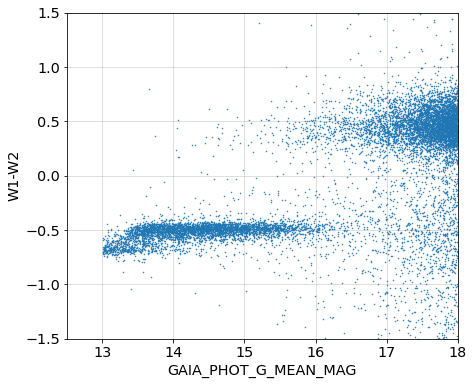

In [14]:
# No cut on GAIA_ASTROMETRIC_EXCESS_NOISE
mask = cat['GAIA_PHOT_G_MEAN_MAG']!=0
# mask &= (cat['GAIA_ASTROMETRIC_EXCESS_NOISE']<10**0.5)
mask &= (cat['GAIA_PHOT_G_MEAN_MAG'] < 18)

plt.figure(figsize=(7, 6))
plt.plot((cat['GAIA_PHOT_G_MEAN_MAG'])[mask], (cat['w1mag']-cat['w2mag'])[mask], '.', ms=1)
plt.xlabel('GAIA_PHOT_G_MEAN_MAG')
plt.ylabel('W1-W2')
plt.grid(alpha=0.5)
plt.axis([12.5, 18, -1.5, 1.5])
plt.show()

In [19]:
from desitarget import targets

In [26]:
ls = Table(fitsio.read('/global/cfs/cdirs/desi/target/analysis/truth/dr9.0/south/matched/ls-dr9.0-sdss-specObj-dr16-unique-trimmed-match.fits', columns=['OBJID', 'BRICKID', 'RELEASE']))
truth = Table(fitsio.read('/global/cfs/cdirs/desi/target/analysis/truth/dr9.0/south/matched/sdss-specObj-dr16-unique-trimmed-match.fits', columns=['Z', 'ZWARNING', 'CLASS']))
print(len(truth))

3141041


In [27]:
ls['TARGETID'] = targets.encode_targetid(ls['OBJID'], ls['BRICKID'], ls['RELEASE'])
truth = hstack([ls[['TARGETID']], truth])

In [28]:
mask = truth['ZWARNING']==0
truth = truth[mask]

In [29]:
mask = np.in1d(cat['TARGETID'], truth['TARGETID'])
cat2 = cat[mask].copy()
print(len(cat2))

mask = np.in1d(truth['TARGETID'], cat2['TARGETID'])
truth = truth[mask]
print(len(truth))

1026507
1026507


In [30]:
cat2 = join(cat2, truth[['TARGETID', 'Z', 'CLASS']], keys='TARGETID')

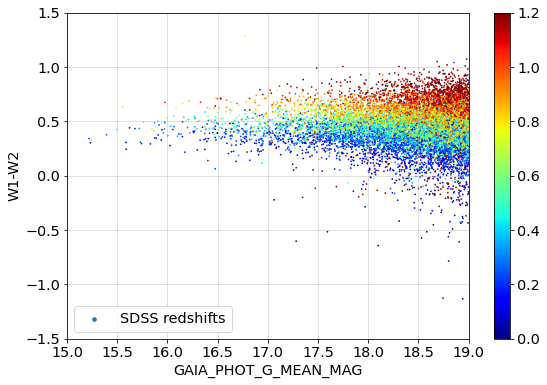

In [66]:
# No cut on GAIA_ASTROMETRIC_EXCESS_NOISE
mask = cat['GAIA_PHOT_G_MEAN_MAG']!=0
# mask &= (cat['GAIA_ASTROMETRIC_EXCESS_NOISE']<10**0.5)
mask &= (cat['GAIA_PHOT_G_MEAN_MAG'] < 20)

mask1 = (cat2['Z']>0.0003) & (cat2['GAIA_PHOT_G_MEAN_MAG'] < 19) & (cat2['GAIA_PHOT_G_MEAN_MAG']!=0)
# mask1 &= np.random.rand(len(cat2))>0.5

plt.figure(figsize=(9, 6))
# plt.plot((cat['GAIA_PHOT_G_MEAN_MAG'])[mask], (cat['w1mag']-cat['w2mag'])[mask], '.', color='0.5', ms=0.5, zorder=0)
plt.scatter((cat2['GAIA_PHOT_G_MEAN_MAG'])[mask1], (cat2['w1mag']-cat2['w2mag'])[mask1], s=0.5, c=cat2['Z'][mask1], cmap='jet', vmin=0., vmax=1.2, zorder=0, label='SDSS redshifts')
plt.colorbar()
plt.xlabel('GAIA_PHOT_G_MEAN_MAG')
plt.ylabel('W1-W2')
plt.grid(alpha=0.5)
plt.axis([15., 19, -1.5, 1.5])
plt.legend(loc='lower left', markerscale=5)
plt.show()

mask2 = mask1 & (cat2['GAIA_PHOT_G_MEAN_MAG'] < 17)
mask3 = mask1 & (cat2['GAIA_PHOT_G_MEAN_MAG'] < 16)
plt.hist(cat2['Z'][mask2], 20, range=(0, 1.2), label='GAIA G<17')
plt.hist(cat2['Z'][mask3], 20, range=(0, 1.2), label='GAIA G<16')
plt.xlabel('GAIA G')
plt.show()

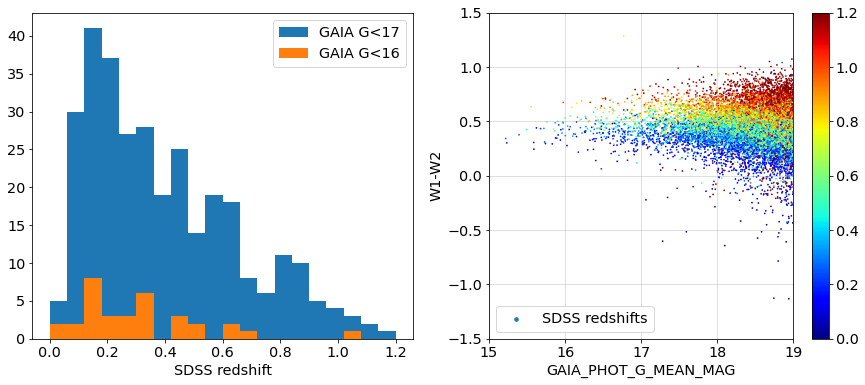

In [78]:
# No cut on GAIA_ASTROMETRIC_EXCESS_NOISE
mask = cat['GAIA_PHOT_G_MEAN_MAG']!=0
# mask &= (cat['GAIA_ASTROMETRIC_EXCESS_NOISE']<10**0.5)
mask &= (cat['GAIA_PHOT_G_MEAN_MAG'] < 20)

mask1 = (cat2['Z']>0.0003) & (cat2['GAIA_PHOT_G_MEAN_MAG'] < 19) & (cat2['GAIA_PHOT_G_MEAN_MAG']!=0)
# mask1 &= np.random.rand(len(cat2))>0.5

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

ax = axes[0]
mask2 = mask1 & (cat2['GAIA_PHOT_G_MEAN_MAG'] < 17)
mask3 = mask1 & (cat2['GAIA_PHOT_G_MEAN_MAG'] < 16)
ax.hist(cat2['Z'][mask2], 20, range=(0, 1.2), label='GAIA G<17')
ax.hist(cat2['Z'][mask3], 20, range=(0, 1.2), label='GAIA G<16')
ax.set_xlabel('SDSS redshift')
ax.legend()

ax = axes[1]
# ax.plot((cat['GAIA_PHOT_G_MEAN_MAG'])[mask], (cat['w1mag']-cat['w2mag'])[mask], '.', color='0.5', ms=0.5, zorder=0)
im  = ax.scatter((cat2['GAIA_PHOT_G_MEAN_MAG'])[mask1], (cat2['w1mag']-cat2['w2mag'])[mask1], s=0.5, c=cat2['Z'][mask1], cmap='jet', vmin=0., vmax=1.2, zorder=0, label='SDSS redshifts')
fig.colorbar(im)
ax.set_xlabel('GAIA_PHOT_G_MEAN_MAG')
ax.set_ylabel('W1-W2')
ax.grid(alpha=0.5)
ax.axis([15., 19, -1.5, 1.5])
ax.legend(loc='lower left', markerscale=5)

plt.show()

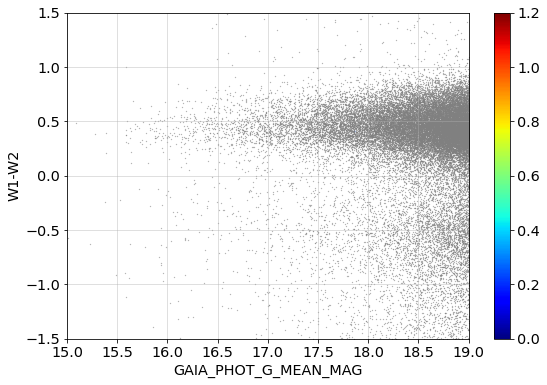

In [63]:
# No cut on GAIA_ASTROMETRIC_EXCESS_NOISE
mask = cat['GAIA_PHOT_G_MEAN_MAG']!=0
# mask &= (cat['GAIA_ASTROMETRIC_EXCESS_NOISE']<10**0.5)
mask &= (cat['GAIA_PHOT_G_MEAN_MAG'] < 20)
mask &= (~mask_remove)

mask1 = (cat2['Z']>0.0003) & (cat2['GAIA_PHOT_G_MEAN_MAG'] < 19) & (cat2['GAIA_PHOT_G_MEAN_MAG']!=0)
# mask1 &= np.random.rand(len(cat2))>0.5

plt.figure(figsize=(9, 6))
plt.plot((cat['GAIA_PHOT_G_MEAN_MAG'])[mask], (cat['w1mag']-cat['w2mag'])[mask], '.', color='0.5', ms=0.5, zorder=0)
plt.scatter((cat2['GAIA_PHOT_G_MEAN_MAG'])[mask1][0], (cat2['w1mag']-cat2['w2mag'])[mask1][0], s=0.5, c=cat2['Z'][mask1][0], cmap='jet', vmin=0., vmax=1.2, zorder=0)
plt.colorbar()
plt.xlabel('GAIA_PHOT_G_MEAN_MAG')
plt.ylabel('W1-W2')
plt.grid(alpha=0.5)
plt.axis([15., 19, -1.5, 1.5])
# plt.legend(loc='lower left')
plt.show()

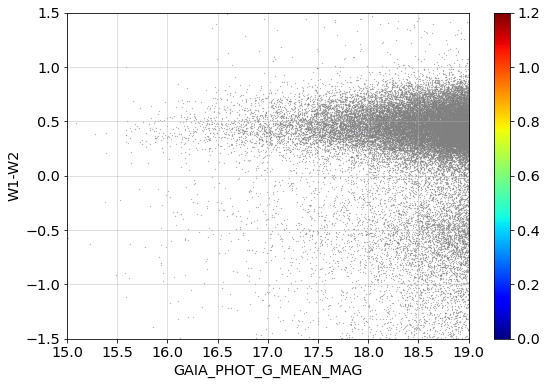

In [64]:
# No cut on GAIA_ASTROMETRIC_EXCESS_NOISE
mask = cat['GAIA_PHOT_G_MEAN_MAG']!=0
mask &= (cat['GAIA_ASTROMETRIC_EXCESS_NOISE']<10**0.5)
mask &= (cat['GAIA_PHOT_G_MEAN_MAG'] < 20)
mask &= (~mask_remove)

mask1 = (cat2['Z']>0.0003) & (cat2['GAIA_PHOT_G_MEAN_MAG'] < 19) & (cat2['GAIA_PHOT_G_MEAN_MAG']!=0)
# mask1 &= np.random.rand(len(cat2))>0.5

plt.figure(figsize=(9, 6))
plt.plot((cat['GAIA_PHOT_G_MEAN_MAG'])[mask], (cat['w1mag']-cat['w2mag'])[mask], '.', color='0.5', ms=0.5, zorder=0)
plt.scatter((cat2['GAIA_PHOT_G_MEAN_MAG'])[mask1][0], (cat2['w1mag']-cat2['w2mag'])[mask1][0], s=0.5, c=cat2['Z'][mask1][0], cmap='jet', vmin=0., vmax=1.2, zorder=0)
plt.colorbar()
plt.xlabel('GAIA_PHOT_G_MEAN_MAG')
plt.ylabel('W1-W2')
plt.grid(alpha=0.5)
plt.axis([15., 19, -1.5, 1.5])
# plt.legend(loc='lower left')
plt.show()

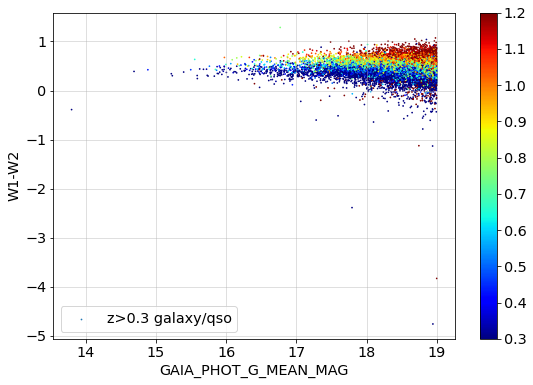

In [48]:
plt.figure(figsize=(9, 6))
# plt.plot((cat['GAIA_PHOT_G_MEAN_MAG'])[mask], (cat['w1mag']-cat['w2mag'])[mask], '.', color='0.5', ms=0.5, zorder=0)
plt.scatter((cat2['GAIA_PHOT_G_MEAN_MAG'])[mask1], (cat2['w1mag']-cat2['w2mag'])[mask1], s=0.5, c=cat2['Z'][mask1], cmap='jet', vmin=0.3, vmax=1.2, zorder=0, label='z>0.3 galaxy/qso')
plt.colorbar()
plt.xlabel('GAIA_PHOT_G_MEAN_MAG')
plt.ylabel('W1-W2')
plt.grid(alpha=0.5)
# plt.axis([15., 19, -1.5, 1.5])
plt.legend(loc='lower left')
plt.show()

In [50]:
t = Table()
t['type'], t['count'] = np.unique(cat2['CLASS'][mask1], return_counts=True)
t.sort('count')
t


type,count
str6,int64
STAR,15
GALAXY,296
QSO,12502


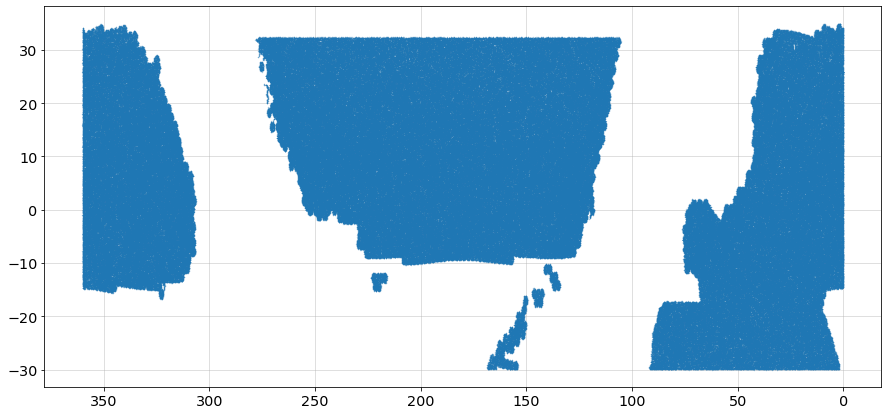

In [81]:
idx = np.random.choice(len(cat), size=int(1e6), replace=False)
plt.figure(figsize=(15, 7))
plt.plot(cat['RA'][idx], cat['DEC'][idx], '.', ms=0.7, alpha=0.5)
plt.grid(alpha=0.5)
plt.gca().invert_xaxis()
plt.show()

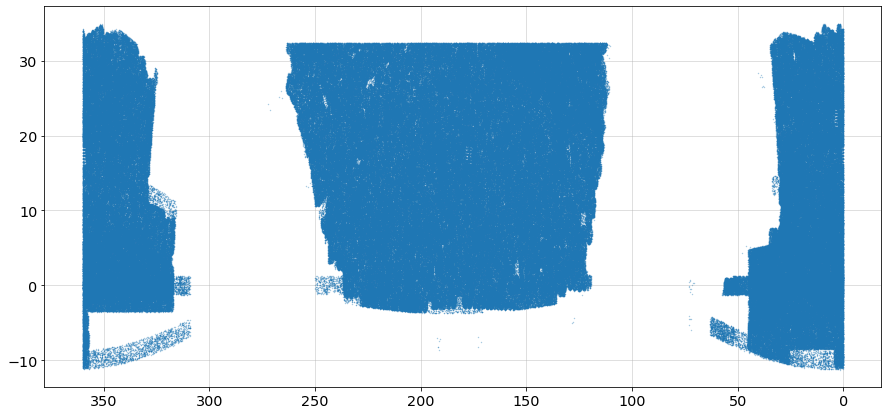

In [82]:
idx = np.random.choice(len(cat2), size=int(1e6), replace=False)
plt.figure(figsize=(15, 7))
plt.plot(cat2['RA'][idx], cat2['DEC'][idx], '.', ms=0.7, alpha=0.5)
plt.grid(alpha=0.5)
plt.gca().invert_xaxis()
plt.show()

In [84]:
ramin, ramax, decmin, decmax = 125, 245, 10, 32
mask = (cat['RA']>ramin) & (cat['RA']<ramax) & (cat['DEC']>decmin) & (cat['DEC']<decmax)
print(np.sum(mask), np.sum(mask)/len(mask))
cat = cat[mask]

mask = (cat2['RA']>ramin) & (cat2['RA']<ramax) & (cat2['DEC']>decmin) & (cat2['DEC']<decmax)
print(np.sum(mask), np.sum(mask)/len(mask))
cat2 = cat2[mask]

5194015 0.20793866203507388
325688 0.31727791432498753


In [86]:
mask_remove = (cat['GAIA_PHOT_G_MEAN_MAG']!=0) & ((cat['GAIA_PHOT_G_MEAN_MAG']<18) & (cat['MASKBITS'] & 2**4>0))
print(np.sum(mask_remove))

1562


6930


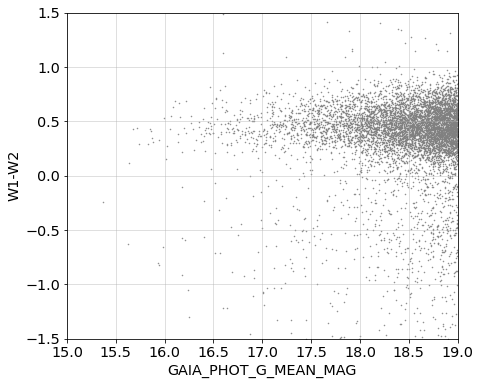

In [94]:
# No cut on GAIA_ASTROMETRIC_EXCESS_NOISE
mask = cat['GAIA_PHOT_G_MEAN_MAG']!=0
# mask &= (cat['GAIA_ASTROMETRIC_EXCESS_NOISE']<10**0.5)
mask &= (cat['GAIA_PHOT_G_MEAN_MAG'] < 19)
mask &= (~mask_remove)
print(np.sum(mask))

plt.figure(figsize=(7, 6))
plt.plot((cat['GAIA_PHOT_G_MEAN_MAG'])[mask], (cat['w1mag']-cat['w2mag'])[mask], '.', color='0.5', ms=1, zorder=0)
plt.xlabel('GAIA_PHOT_G_MEAN_MAG')
plt.ylabel('W1-W2')
plt.grid(alpha=0.5)
plt.axis([15., 19, -1.5, 1.5])
# plt.legend(loc='lower left')
plt.show()

1656


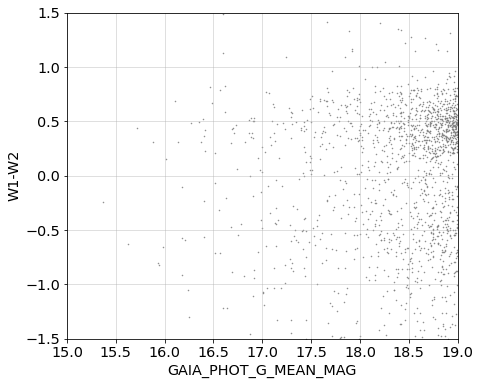

In [93]:
# No cut on GAIA_ASTROMETRIC_EXCESS_NOISE
mask = cat['GAIA_PHOT_G_MEAN_MAG']!=0
# mask &= (cat['GAIA_ASTROMETRIC_EXCESS_NOISE']<10**0.5)
mask &= (cat['GAIA_PHOT_G_MEAN_MAG'] < 19)
mask &= (~mask_remove)
mask &= ~np.in1d(cat['TARGETID'], cat2['TARGETID'])
print(np.sum(mask))

plt.figure(figsize=(7, 6))
plt.plot((cat['GAIA_PHOT_G_MEAN_MAG'])[mask], (cat['w1mag']-cat['w2mag'])[mask], '.', color='0.5', ms=1, zorder=0)
plt.xlabel('GAIA_PHOT_G_MEAN_MAG')
plt.ylabel('W1-W2')
plt.grid(alpha=0.5)
plt.axis([15., 19, -1.5, 1.5])
# plt.legend(loc='lower left')
plt.show()